In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astroquery.mast import Observations

---
## COS test

STIS done. Now COS. First lets just find a SN that actually has some COS UV data and pull MAST's default x1d to look at it. COS is photon-counting (calcos), so apparently custom extraction later is a different beast than stistools.x1d (edit XTRACTAB boxes + rerun calcos).


In [13]:
# find SNe with COS spectra. target_name is proposer-typed but a lot of SNe do get logged as 'SN*'
cos = Observations.query_criteria(obs_collection="HST", instrument_name="COS*", target_name="SN*")
print(f"{len(cos)} COS obs under SN* names")

# collapse to unique targets so we can pick one
from astropy.table import unique
u = unique(cos, keys="target_name")
u["target_name", "filters", "t_exptime", "proposal_id"]


148 COS obs under SN* names


target_name,filters,t_exptime,proposal_id
str19,str41,float64,str5
SN 1895B,G130M;G160M,8166.656000000001,MULTI
SN 1968L,G130M;G160M,3084.2239999999997,MULTI
SN 1983I,E140M;G130M;G160M;G750M,20644.528,MULTI
SN 1987A,G130M;G160M;G230L;G430L;G430M;G750L;G750M,54153.52799999999,MULTI
SN 1993J,G140L;G230L,29968.127999999997,12531
SN 2009ip,G130M;G140L;G160M;G230LB;G430L;G750L,10719.864,MULTI
SN 2010al,G140L;G230LB;G430L,8400.0,11654
SN 2010jl,G130M;G140L;G160M;G230L;G430L,20549.688,MULTI
SN 2014C,G140L;G230LB;G430L,10617.648000000001,14202


In [ ]:
# go with SN2023ixf - type II in M101. dedicated COS G230L visit (prop 17497)
ixf = Observations.query_criteria(objectname="SN2023ixf", obs_collection="HST", instrument_name="COS*", radius="0.01 deg") # before it was 3 arcmin, made smaller to 0.01-0.02 deg ~ 0.6 arcmin
print(f"{len(ixf)} COS obs near SN2023ixf")
ixf["obs_id", "instrument_name", "filters", "t_exptime", "target_name", "proposal_id"]


10 COS obs near SN2023ixf


obs_id,instrument_name,filters,t_exptime,target_name,proposal_id
str37,str8,str23,float64,str13,str5
ldjia3010,COS/FUV,G140L,1972.0,+254.6-107.2,15126
lf8803050,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
hst_hsla_sn2023ixf--3586,COS-STIS,G140L;G230L;G430L;G750L,12697.126625,SN 2023ixf,MULTI
lf8803d3q,COS/NUV,MIRRORA,5.0,SN2023IXF-COS,17497
lf8803030,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
lf8803040,COS/NUV,G230L,629.184,SN2023IXF-COS,17497
lf8803010,COS/NUV,G230L,1700.192,SN2023IXF-COS,17497
lf8803020,COS/NUV,G230L,337.0,SN2023IXF-COS,17497
hst_hasp_17497_cos_sn2023ixf-cos_lf88,COS,G230L,6704.928,SN2023IXF-COS,17497


In [15]:
# grab one COS/NUV G230L exposure and pull its default x1dsum (the summed 1d product)
one = ixf[ixf["obs_id"] == "lf8803010"]
cprod = Observations.get_product_list(one)
cx1d = Observations.filter_products(cprod, productSubGroupDescription=["X1DSUM", "X1D"], extension="fits")
cman = Observations.download_products(cx1d, download_dir="./Data/2023ixf")
cman["Local Path", "Status"]


Local Path,Status
str63,str8
./Data/2023ixf\mastDownload\HST\lf8803010\lf8803010_x1dsum.fits,COMPLETE
./Data/2023ixf\mastDownload\HST\lf8803d5q\lf8803d5q_x1d.fits,COMPLETE


3 stripes: ['NUVA', 'NUVB', 'NUVC']


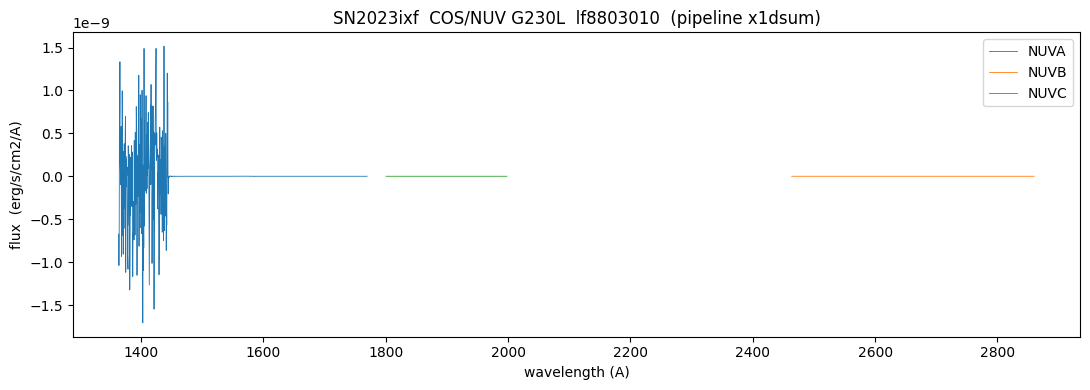

In [16]:
# COS NUV lands on 3 stripes (NUVA/B/C) so the x1dsum has 3 rows. COS masks on DQ_WGT (0 = thrown out)
cosx1d = "./Data/2023ixf/mastDownload/HST/lf8803010/lf8803010_x1dsum.fits"
ct = Table.read(cosx1d, hdu=1)
print(len(ct), "stripes:", list(ct['SEGMENT']))

plt.figure(figsize=(11, 4))
for r in ct:
    w, f, dqw = r['WAVELENGTH'], r['FLUX'], r['DQ_WGT']
    m = dqw > 0
    plt.plot(w[m], f[m], lw=0.6, label=r['SEGMENT'])
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  lf8803010  (pipeline x1dsum)'); plt.legend()
plt.tight_layout(); plt.show()


INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_asn.fits with expected size 11520. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_jif.fits with expected size 34560. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_jit.fits with expected size 77760. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_trl.fits with expected size 8640. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum3.fits with expected size 259200. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum_prev.fits with expected size 115200. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\lf8803050_x1dsum3_prev.fits with expected size 115200. [astroquery.query]
INFO: Found cached file ./Data/2023ixf\mastDownload\HST\lf8803050\l

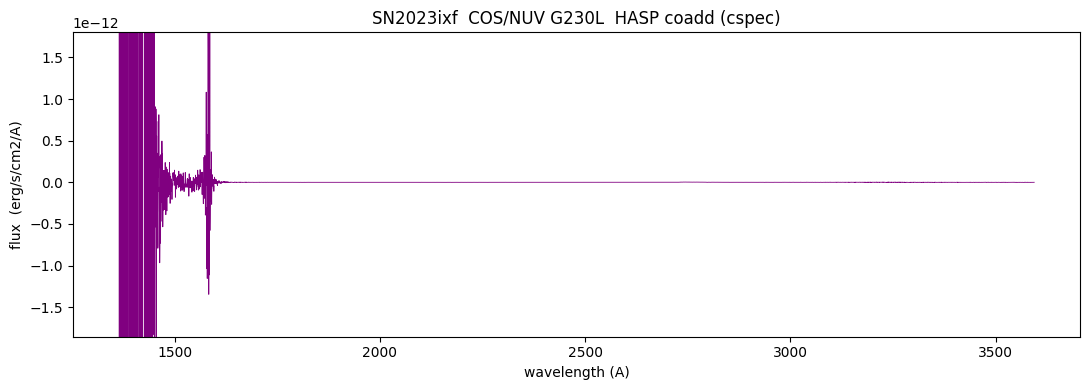

In [ ]:
# i guess one exposure is faint. lets try grabbing the HASP coadd of the whole G230L visit for a clean look (details in data_access)
hasp = ixf[ixf["obs_id"] == "hst_hasp_17497_cos_sn2023ixf-cos_lf88"]
hprod = Observations.get_product_list(hasp)
hman = Observations.download_products(hprod, download_dir="./Data/2023ixf", extension="fits")
cspec_path = [p for p in hman["Local Path"] if p.endswith("cspec.fits")][0]

hc = Table.read(cspec_path, hdu=1)
w, f, eff = hc['WAVELENGTH'][0], hc['FLUX'][0], hc['EFF_EXPTIME'][0]
# only where there's real coadded coverage. the blue edge has huge-error spikes that wreck the y-scale, so clip those
m = (eff > 0) & np.isfinite(f)
lo, hi = np.nanpercentile(f[m], [2, 98])

plt.figure(figsize=(11, 4))
plt.plot(w[m], f[m], lw=0.6, color='purple')
plt.ylim(lo - abs(lo), hi * 1.3)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  HASP coadd (cspec)')
plt.tight_layout(); plt.show() # uh oh that pulled the full product set (all the rawtag/corrtag/flt too, not just cspec)
# NOTE: ^ can use these as calcos inputs later


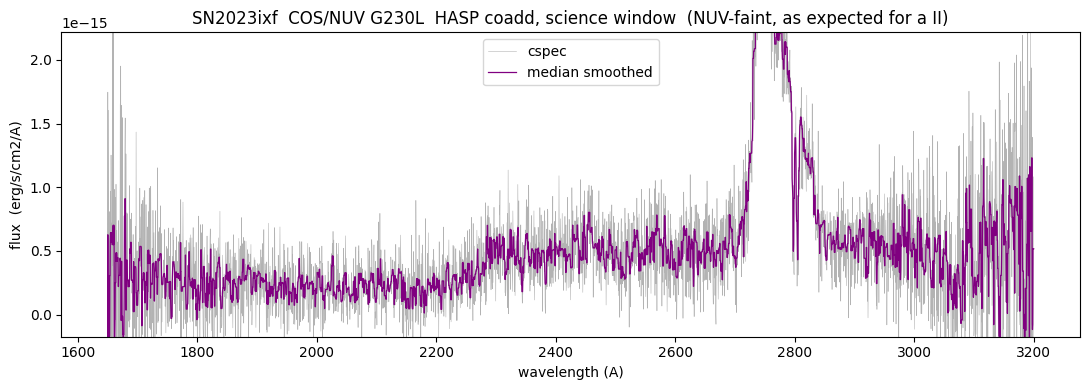

In [20]:
# zoom into the actual G230L science window (the blue end <1650 is 2nd-order/airglow junk).
# uses the in-memory cspec from the cell above so no re-download.
from scipy.ndimage import median_filter
sci = m & (w > 1650) & (w < 3200)
wsci = np.asarray(w[sci], dtype=float)
fsci = np.asarray(f[sci], dtype=float)   # fits is big-endian, scipy wants native
fs = median_filter(fsci, size=7)         # light smooth just to see the continuum shape
lo, hi = np.nanpercentile(fsci, [5, 95])

plt.figure(figsize=(11, 4))
plt.plot(wsci, fsci, lw=0.4, color='0.7', label='cspec')
plt.plot(wsci, fs, lw=0.9, color='purple', label='median smoothed')
plt.ylim(lo - abs(lo), hi * 1.4)
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)')
plt.title('SN2023ixf  COS/NUV G230L  HASP coadd, science window  (NUV-faint, as expected for a II)')
plt.legend(); plt.tight_layout(); plt.show()


---
## COS custom extraction (calcos + XTRACTAB)

calcos is the COS pipeline (pure python, separate from hstcal). it runs in the same WSL surf_uv env. the COS analog of the STIS trace+aperture is the XTRACTAB: it holds the extraction box (B_SPEC center, HEIGHT) + bg boxes per stripe/grating/cenwave. NUV uses BOXCAR extraction so editing the boxes just works (FUV defaults to TWOZONE, would need XTRCTALG=BOXCAR).

workflow (all in WSL): sync COS refs -> `reduce_cos.py` runs calcos default -> `reduce_cos_custom.py` copies the XTRACTAB, narrows the source box HEIGHT (57 -> 15), points a copy of the corrtag at it, re-runs calcos. here we compare.


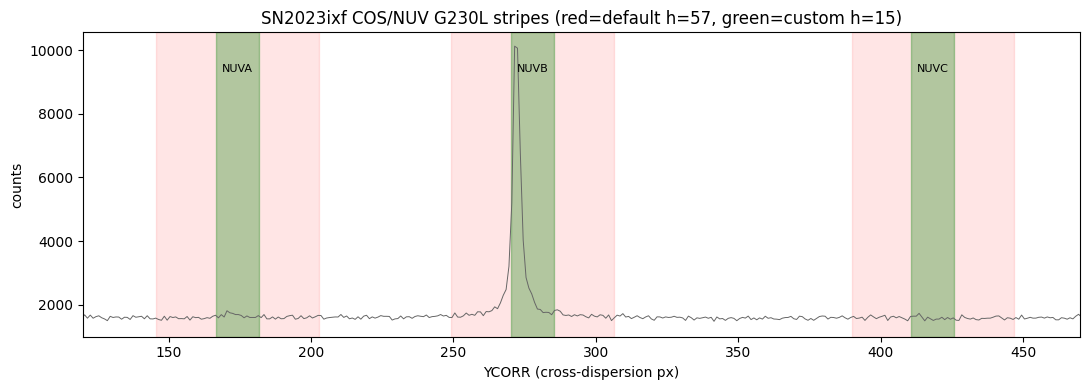

In [2]:
# collapse the corrtag counts onto the cross-dispersion (Y) axis to see the 3 NUV stripes + our boxes
ct = "./Data/2023ixf/mastDownload/HST/lf8803d5q/lf8803d5q_corrtag.fits"
ev = Table.read(ct, hdu=1)
yprof, yedges = np.histogram(ev['YCORR'], bins=np.arange(0, 1025))
yc = 0.5 * (yedges[:-1] + yedges[1:])

# read the actual box heights from the original + edited xtractab
to = Table.read("./crds_cache/references/hst/cos/69f1919fl_1dx.fits", hdu=1)
te = Table.read("./Data/2023ixf/cos_work/edit_1dx.fits", hdu=1)
sel = (to['OPT_ELEM'] == 'G230L') & (to['CENWAVE'] == 2635) & (to['APERTURE'] == 'PSA')
rows, erows = to[sel], te[sel]

plt.figure(figsize=(11, 4))
plt.plot(yc, yprof, lw=0.7, color='0.4')
for r, er in zip(rows, erows):
    b, hd, hc = r['B_SPEC'], r['HEIGHT'], er['HEIGHT']
    plt.axvspan(b - hd/2, b + hd/2, color='red', alpha=0.10)     # default box
    plt.axvspan(b - hc/2, b + hc/2, color='green', alpha=0.30)   # our narrow box
    plt.text(b, yprof.max()*0.92, r['SEGMENT'], ha='center', fontsize=8)
plt.xlim(120, 470); plt.xlabel('YCORR (cross-dispersion px)'); plt.ylabel('counts')
plt.title(f"SN2023ixf COS/NUV G230L stripes (red=default h={rows['HEIGHT'][0]}, green=custom h={erows['HEIGHT'][0]})")
plt.tight_layout(); plt.show()


NUVA: flux std  default=2.65e-10  custom=1.28e-10
NUVB: flux std  default=8.11e-16  custom=7.03e-16
NUVC: flux std  default=4.84e-15  custom=2.49e-15


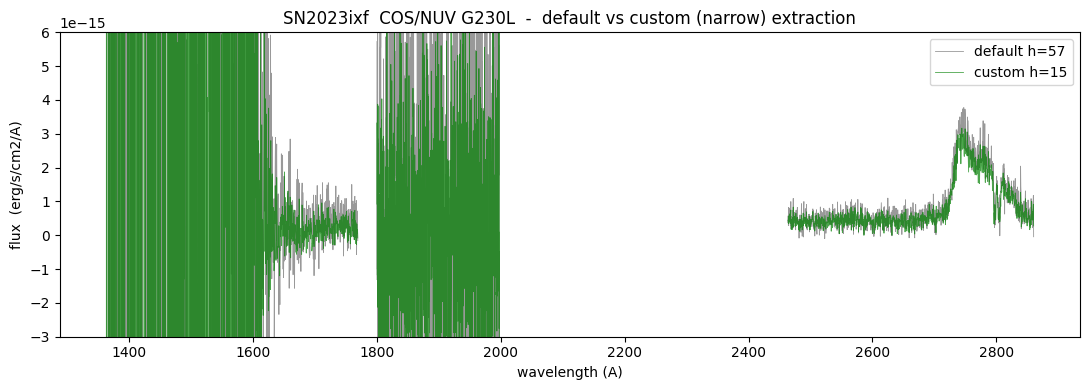

In [4]:
# default vs custom (narrow box) extracted spectra, all 3 NUV stripes
xd = Table.read("./Data/2023ixf/cos_out_default/lf8803d5q_x1d.fits", hdu=1)
xc = Table.read("./Data/2023ixf/cos_out_custom/lf8803d5q_x1d.fits", hdu=1)

plt.figure(figsize=(11, 4))
for i in range(len(xd)):
    seg = xd['SEGMENT'][i]
    wd, fd, gd = xd['WAVELENGTH'][i], xd['FLUX'][i], xd['DQ_WGT'][i] > 0
    wc, fc, gc = xc['WAVELENGTH'][i], xc['FLUX'][i], xc['DQ_WGT'][i] > 0
    plt.plot(wd[gd], fd[gd], lw=0.6, color='0.6', label='default h=57' if i == 0 else None)
    plt.plot(wc[gc], fc[gc], lw=0.6, color='green', alpha=0.7, label='custom h=15' if i == 0 else None)
    # narrower box should let in less background -> lower flux scatter
    print(f"{seg}: flux std  default={np.nanstd(fd[gd]):.2e}  custom={np.nanstd(fc[gc]):.2e}")
plt.ylim(-3e-15, 6e-15)   # the SN is NUV-faint, clip the contaminated-stripe noise spikes
plt.xlabel('wavelength (A)'); plt.ylabel('flux  (erg/s/cm2/A)'); plt.legend()
plt.title('SN2023ixf  COS/NUV G230L  -  default vs custom (narrow) extraction')
plt.tight_layout(); plt.show()
